In [1]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../Augmente'))

import random
from PIL import Image, ImageDraw, ImageFilter, ImageChops
import matplotlib.pyplot as plt

import StitchingEffect as stitching_effect_module
importlib.reload(stitching_effect_module)
RandomStitchingEffect = stitching_effect_module.RandomStitchingEffect

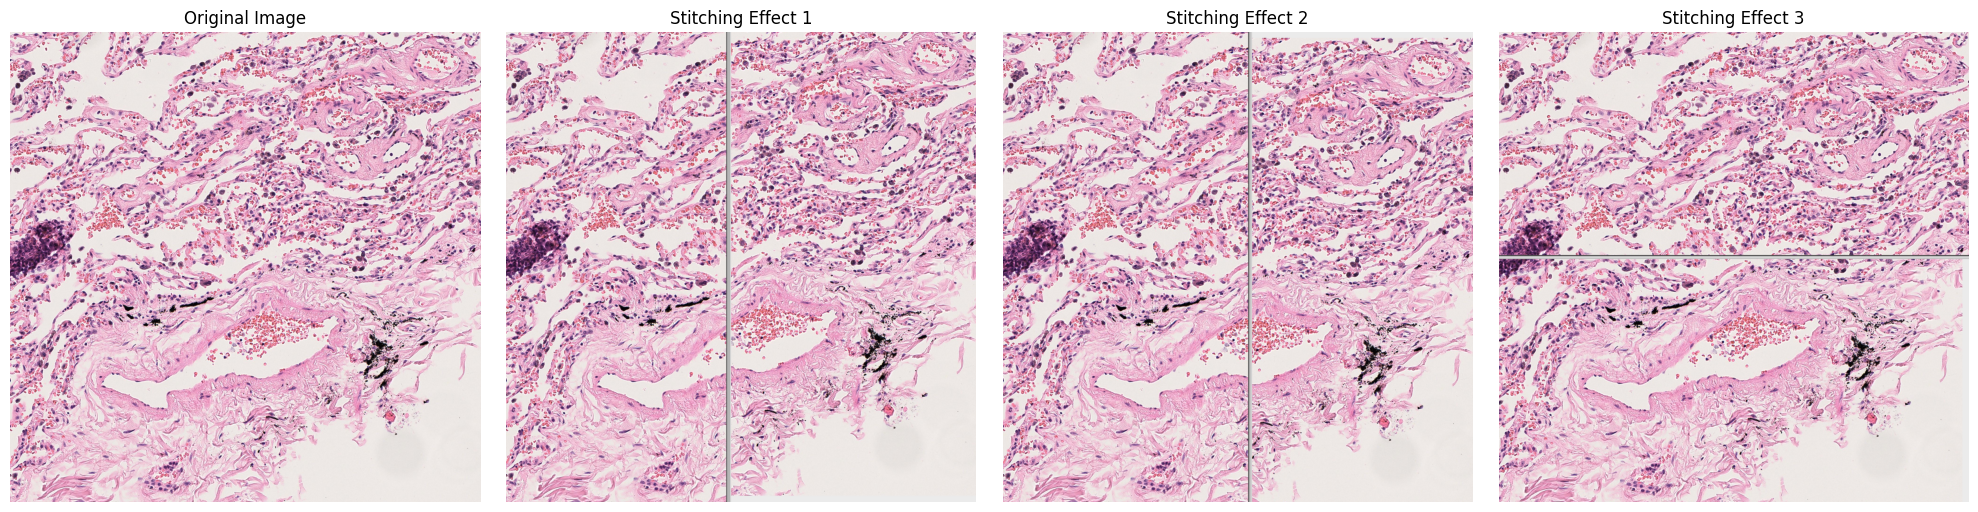

In [2]:
stiching_transform = RandomStitchingEffect(
    p=1.0,
    max_shift=36,
    max_gap=14,
    min_gap=8,
    seam_line_prob=1.0,
    seam_line_width_range=(3, 5),
    split_ratio_range=(0.42, 0.58),
)

sample_img_dir = os.path.join('..', 'dataset_split', 'test', 'image')
image_files = [f for f in os.listdir(sample_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
sample_img = Image.open(os.path.join(sample_img_dir, image_files[0])).convert('RGB')

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].set_title('Original Image')
ax[0].imshow(sample_img)
ax[0].axis('off')

for i in range(1, 4):
    transformed_image = stiching_transform(sample_img)
    ax[i].set_title(f'Stitching Effect {i}')
    ax[i].imshow(transformed_image)
    ax[i].axis('off')
    
plt.tight_layout()
plt.show()